# ⚽ FIFA World Cup Score Predictor
## Multi-Model Training Framework

This notebook trains multiple ML models to predict:
1. Final score (home & away goals)
2. Match outcome (win/draw/loss)
3. Total goals
4. Goal difference

### Step 0: Install Dependencies

In [1]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn -q
print("✓ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✓ Dependencies installed



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Import & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit,
                                     RandomizedSearchCV, cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, PoissonRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBRegressor, XGBClassifier

print("\u2713 All libraries imported successfully")

✓ All libraries imported successfully


In [3]:
# Load the FIFA World Cup dataset
# Download from: https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup/data

df = pd.read_csv('FIFA_WC.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (964, 44)

Columns:
['Home Team Name', 'Away Team Name', 'Home Team Goals', 'home_xg', 'home_penalty', 'Away Team Goals', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'DateTime', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']

First 5 rows:


,Home Team Name,Away Team Name,Home Team Goals,home_xg,home_penalty,Away Team Goals,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 2026 FIFA WORLD CUP — ACTUAL RESULTS (Group Stage, as of June 24 2026)
# Source: Yahoo Sports / ESPN / Olympics.com live results
# ══════════════════════════════════════════════════════════════════════════════

wc2026_matches = [
    # ── Group A ────────────────────────────────────────────────────────────
    ('Mexico',       'South Africa', 2, 0, '2026-06-11', 'Group A'),
    ('Korea Republic','Czechia',     2, 1, '2026-06-11', 'Group A'),
    ('Czechia',      'South Africa', 1, 1, '2026-06-18', 'Group A'),
    ('Mexico',       'Korea Republic',1,0, '2026-06-18', 'Group A'),
    # ── Group B ────────────────────────────────────────────────────────────
    ('Canada',       'Bosnia and Herzegovina', 1, 1, '2026-06-12', 'Group B'),
    ('Switzerland',  'Qatar',        1, 1, '2026-06-13', 'Group B'),
    ('Switzerland',  'Bosnia and Herzegovina', 4, 1, '2026-06-18', 'Group B'),
    ('Canada',       'Qatar',        6, 0, '2026-06-18', 'Group B'),
    # ── Group C ────────────────────────────────────────────────────────────
    ('Brazil',       'Morocco',      1, 1, '2026-06-13', 'Group C'),
    ('Scotland',     'Haiti',        1, 0, '2026-06-13', 'Group C'),
    ('Scotland',     'Morocco',      0, 1, '2026-06-19', 'Group C'),
    ('Brazil',       'Haiti',        3, 0, '2026-06-19', 'Group C'),
    # ── Group D ────────────────────────────────────────────────────────────
    ('United States','Paraguay',     4, 1, '2026-06-12', 'Group D'),
    ('Australia',    'Türkiye',      2, 0, '2026-06-13', 'Group D'),
    ('United States','Australia',    2, 0, '2026-06-19', 'Group D'),
    ('Türkiye',      'Paraguay',     0, 1, '2026-06-19', 'Group D'),
    # ── Group E ────────────────────────────────────────────────────────────
    ('Germany',      'Curaçao',      7, 1, '2026-06-14', 'Group E'),
    ("Côte d'Ivoire",'Ecuador',      1, 0, '2026-06-14', 'Group E'),
    ('Germany',      "Côte d'Ivoire",2, 1, '2026-06-20', 'Group E'),
    ('Ecuador',      'Curaçao',      0, 0, '2026-06-20', 'Group E'),
    # ── Group F ────────────────────────────────────────────────────────────
    ('Netherlands',  'Japan',        2, 2, '2026-06-14', 'Group F'),
    ('Sweden',       'Tunisia',      5, 1, '2026-06-14', 'Group F'),
    ('Netherlands',  'Sweden',       5, 1, '2026-06-20', 'Group F'),
    ('Japan',        'Tunisia',      4, 0, '2026-06-20', 'Group F'),
    # ── Group G ────────────────────────────────────────────────────────────
    ('Belgium',      'Egypt',        1, 1, '2026-06-15', 'Group G'),
    ('IR Iran',      'New Zealand',  2, 2, '2026-06-15', 'Group G'),
    ('Belgium',      'IR Iran',      0, 0, '2026-06-21', 'Group G'),
    ('Egypt',        'New Zealand',  3, 1, '2026-06-21', 'Group G'),
    # ── Group H ────────────────────────────────────────────────────────────
    ('Spain',        'Cape Verde',   0, 0, '2026-06-15', 'Group H'),
    ('Saudi Arabia', 'Uruguay',      1, 1, '2026-06-15', 'Group H'),
    ('Spain',        'Saudi Arabia', 4, 0, '2026-06-21', 'Group H'),
    ('Uruguay',      'Cape Verde',   2, 2, '2026-06-21', 'Group H'),
    # ── Group I ────────────────────────────────────────────────────────────
    ('France',       'Senegal',      3, 1, '2026-06-16', 'Group I'),
    ('Norway',       'Iraq',         4, 1, '2026-06-16', 'Group I'),
    ('France',       'Iraq',         3, 0, '2026-06-22', 'Group I'),
    ('Norway',       'Senegal',      3, 2, '2026-06-22', 'Group I'),
    # ── Group J ────────────────────────────────────────────────────────────
    ('Argentina',    'Algeria',      3, 0, '2026-06-16', 'Group J'),
    ('Austria',      'Jordan',       3, 1, '2026-06-16', 'Group J'),
    ('Argentina',    'Austria',      2, 0, '2026-06-22', 'Group J'),
    ('Jordan',       'Algeria',      1, 2, '2026-06-22', 'Group J'),
    # ── Group K ────────────────────────────────────────────────────────────
    ('Portugal',     'Congo DR',     1, 1, '2026-06-17', 'Group K'),
    ('Uzbekistan',   'Colombia',     1, 3, '2026-06-17', 'Group K'),
    ('Portugal',     'Uzbekistan',   5, 0, '2026-06-23', 'Group K'),
    ('Colombia',     'Congo DR',     1, 0, '2026-06-23', 'Group K'),
    # ── Group L ────────────────────────────────────────────────────────────
    ('England',      'Croatia',      4, 2, '2026-06-17', 'Group L'),
    ('Ghana',        'Panama',       1, 0, '2026-06-17', 'Group L'),
    ('England',      'Ghana',        0, 0, '2026-06-23', 'Group L'),
    ('Panama',       'Croatia',      0, 1, '2026-06-23', 'Group L'),
]

cols = ['Home Team Name', 'Away Team Name', 'Home Team Goals', 'Away Team Goals', 'DateTime', 'Round']
df_2026 = pd.DataFrame(wc2026_matches, columns=cols)
df_2026['Year']  = 2026
df_2026['Host']  = 'USA/Canada/Mexico'
df_2026['Score'] = df_2026.apply(
    lambda r: f"{int(r['Home Team Goals'])}-{int(r['Away Team Goals'])}", axis=1)

# Fill remaining columns that exist in main df with NaN
for col in df.columns:
    if col not in df_2026.columns:
        df_2026[col] = np.nan

df = pd.concat([df, df_2026[df.columns]], ignore_index=True)

print(f"✓ 2026 actual results appended — {len(df_2026)} matches")
print(f"  Total dataset: {len(df)} matches  |  Years: {int(df['Year'].min())}–{int(df['Year'].max())}")
print(f"\n  2026 avg goals/game : {(df_2026['Home Team Goals']+df_2026['Away Team Goals']).mean():.2f}")
print(f"  2026 home win rate  : {(df_2026['Home Team Goals'] > df_2026['Away Team Goals']).mean():.1%}")
print(f"  2026 draw rate      : {(df_2026['Home Team Goals'] == df_2026['Away Team Goals']).mean():.1%}")
print(f"  2026 away win rate  : {(df_2026['Home Team Goals'] < df_2026['Away Team Goals']).mean():.1%}")

✓ 2026 actual results appended — 48 matches
  Total dataset: 1012 matches  |  Years: 1930–2026

  2026 avg goals/game : 2.94
  2026 home win rate  : 60.4%
  2026 draw rate      : 29.2%
  2026 away win rate  : 10.4%


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nData info:")
df.info()

Missing values:
Home Team Name                        0
Away Team Name                        0
Home Team Goals                       0
home_xg                             884
home_penalty                        977
Away Team Goals                       0
away_xg                             884
away_penalty                        977
home_manager                         48
home_captain                        368
away_manager                         48
away_captain                        368
Attendance                           48
Venue                                48
Officials                           303
Round                                 0
DateTime                              0
Score                                 0
Referee                             303
Notes                               939
Host                                  0
Year                                  0
home_goal                           294
away_goal                           441
home_goal_long          

### Step 2: Data Exploration

Goal statistics:
       Home Team Goals  Away Team Goals
count      1012.000000      1012.000000
mean          1.796443         1.030632
std           1.604293         1.060042
min           0.000000         0.000000
25%           1.000000         0.000000
50%           1.000000         1.000000
75%           3.000000         2.000000
max          10.000000         7.000000


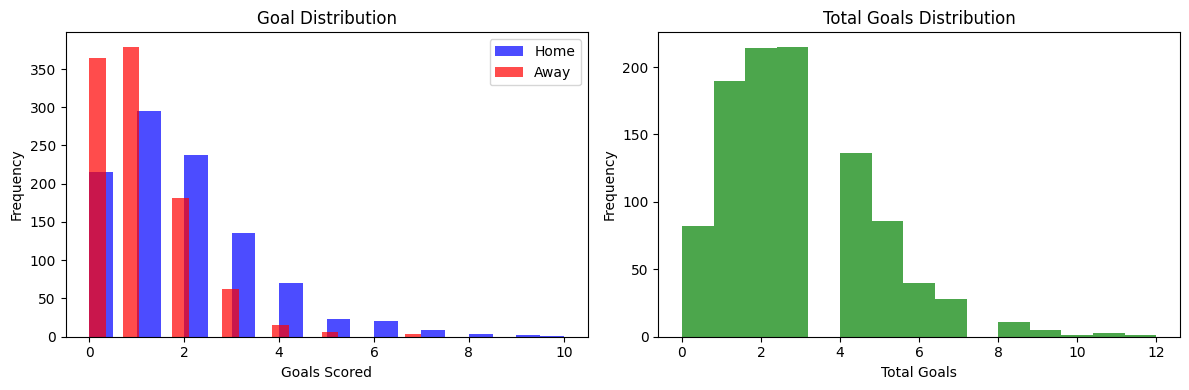


Average home goals: 1.80
Average away goals: 1.03
Average total goals per match: 2.83


In [6]:
# Basic statistics
print("Goal statistics:")
print(df[['Home Team Goals', 'Away Team Goals']].describe())

# Visualize goal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Home Team Goals'], bins=20, alpha=0.7, label='Home', color='blue')
axes[0].hist(df['Away Team Goals'], bins=20, alpha=0.7, label='Away', color='red')
axes[0].set_xlabel('Goals Scored')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_title('Goal Distribution')

# Total goals distribution
total_goals = df['Home Team Goals'] + df['Away Team Goals']
axes[1].hist(total_goals, bins=15, color='green', alpha=0.7)
axes[1].set_xlabel('Total Goals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Total Goals Distribution')
plt.tight_layout()
plt.show()

print(f"\nAverage home goals: {df['Home Team Goals'].mean():.2f}")
print(f"Average away goals: {df['Away Team Goals'].mean():.2f}")
print(f"Average total goals per match: {total_goals.mean():.2f}")

### Step 3: Feature Engineering

In [7]:
# Create target variables
df['home_goals'] = df['Home Team Goals']
df['away_goals'] = df['Away Team Goals']
df['total_goals'] = df['home_goals'] + df['away_goals']
df['goal_difference'] = df['home_goals'] - df['away_goals']

# Outcome: 2=Home Win, 1=Draw, 0=Away Win (non-negative integers required by XGBoost)
df['outcome'] = df['goal_difference'].apply(lambda x: 2 if x > 0 else (1 if x == 0 else 0))

# Parse year
df['year'] = pd.to_datetime(df['DateTime']).dt.year

print("✓ Target variables created")
print(f"\nOutcome distribution:")
outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
print(df['outcome'].value_counts().map(outcome_map))

✓ Target variables created

Outcome distribution:
outcome
2    NaN
1    NaN
0    NaN
Name: count, dtype: object


In [8]:
# ── ELO Ratings (June 2026, sourced from eloratings.net) ──────────────────────
elo_ratings = {
    'Argentina': 2145, 'France': 2095, 'England': 2065, 'Brazil': 2060,
    'Spain': 2055, 'Portugal': 2040, 'Netherlands': 2020, 'Germany': 2010,
    'Belgium': 1995, 'Italy': 1990, 'Uruguay': 1975, 'Croatia': 1970,
    'Denmark': 1960, 'Switzerland': 1955, 'Colombia': 1945, 'Mexico': 1875,
    'Norway': 1940, 'Sweden': 1930, 'USA': 1890, 'United States': 1890,
    'Japan': 1870, 'Morocco': 1870, 'Senegal': 1855, 'Ecuador': 1840,
    'Austria': 1985, 'Australia': 1840, 'Korea Republic': 1835,
    'Canada': 1825, 'Ghana': 1815, 'Cameroon': 1810, 'Peru': 1815,
    'Egypt': 1810, 'Iran': 1800, 'IR Iran': 1800, 'Algeria': 1795,
    'Türkiye': 1860, 'Turkey': 1860, 'Serbia': 1820, 'Poland': 1820,
    'Ukraine': 1825, 'Chile': 1810, 'Paraguay': 1790, 'Tunisia': 1770,
    'Saudi Arabia': 1780, 'Qatar': 1710, 'Bolivia': 1740, 'Costa Rica': 1760,
    "Côte d'Ivoire": 1835, 'Ivory Coast': 1835,
    'Scotland': 1820, 'South Africa': 1600, 'New Zealand': 1680,
    'Panama': 1680, 'Iraq': 1700, 'Jordan': 1720, 'Czechia': 1780,
    'Cape Verde': 1720, 'Uzbekistan': 1700, 'Congo DR': 1710, 'DR Congo': 1710,
    'Haiti': 1610, 'Curaçao': 1600, 'Bosnia and Herzegovina': 1760,
    'West Germany': 2015, 'Soviet Union': 1960, 'Yugoslavia': 1910,
    'Czechoslovakia': 1890, 'German Democratic Republic': 1820,
    'Dutch East Indies': 1500, 'Zaire': 1580, 'North Korea': 1660,
    'Cuba': 1550, 'Republic of Ireland': 1790,
}

squad_ages = {
    'Argentina': 27.8, 'France': 26.4, 'England': 26.8, 'Brazil': 26.2,
    'Spain': 25.6, 'Portugal': 27.9, 'Netherlands': 26.5, 'Germany': 25.8,
    'Belgium': 29.1, 'Uruguay': 28.3, 'Croatia': 30.1, 'Switzerland': 27.6,
    'Colombia': 26.9, 'Norway': 25.4, 'Sweden': 26.2, 'Japan': 26.1,
    'Morocco': 26.7, 'Australia': 27.2, 'Korea Republic': 27.0,
    'Canada': 26.2, 'Mexico': 26.8, 'USA': 25.4, 'United States': 25.4,
    "Côte d'Ivoire": 28.2, 'Ivory Coast': 28.2, 'Egypt': 27.5,
    'Iran': 28.0, 'IR Iran': 28.0, 'Algeria': 26.8,
    'Türkiye': 26.5, 'Turkey': 26.5, 'Scotland': 27.1, 'Austria': 26.6,
    'Saudi Arabia': 26.4, 'Ecuador': 26.5, 'Ghana': 26.9, 'Serbia': 28.0,
    'Denmark': 26.5, 'Poland': 28.3, 'Senegal': 27.3,
}

print(f'\u2713 ELO ratings loaded \u2014 {len(elo_ratings)} teams')
print(f'\u2713 Squad ages loaded  \u2014 {len(squad_ages)} teams')

try:
    elo_df = pd.read_csv('elo_ratings.csv')
    latest = elo_df.sort_values('year').groupby('team').last()['rating'].to_dict()
    elo_ratings.update(latest)
    print(f'  Updated from elo_ratings.csv \u2014 {len(latest)} teams')
except FileNotFoundError:
    pass

try:
    ages_df = pd.read_csv('squad_ages_2026.csv')
    squad_ages.update(ages_df.set_index('team')['avg_age'].to_dict())
    print(f'  Updated from squad_ages_2026.csv \u2014 {len(ages_df)} teams')
except FileNotFoundError:
    pass

# ── Dynamic ELO: update from 2026 group stage results ─────────────────────────
def update_elo_ratings(elo_dict, matches_list, k=40):
    elo = elo_dict.copy()
    for m in matches_list:
        home, away, hg, ag = m[0], m[1], m[2], m[3]
        h_e = elo.get(home, 1600)
        a_e = elo.get(away, 1600)
        exp = 1 / (1 + 10 ** ((a_e - h_e) / 400))
        act = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
        elo[home] = h_e + k * (act - exp)
        elo[away] = a_e + k * ((1 - act) - (1 - exp))
    return elo

elo_ratings_updated = update_elo_ratings(elo_ratings, wc2026_matches, k=40)

print('\n\u2713 ELO updated from 2026 group stage results \u2014 notable changes:')
highlight = ['Argentina', 'France', 'Norway', 'United States', 'Germany',
             'Spain', 'Colombia', 'England', 'Belgium', 'Brazil']
for team in highlight:
    old = elo_ratings.get(team, 1600)
    new = elo_ratings_updated.get(team, 1600)
    print(f'  {team:<20}: {old:.0f} \u2192 {new:.0f} ({new-old:+.0f})')


✓ ELO ratings loaded — 73 teams
✓ Squad ages loaded  — 40 teams

✓ ELO updated from 2026 group stage results — notable changes:
  Argentina           : 2145 → 2161 (+16)
  France              : 2095 → 2106 (+11)
  Norway              : 1940 → 1962 (+22)
  United States       : 1890 → 1922 (+32)
  Germany             : 2010 → 2025 (+15)
  Spain               : 2055 → 2048 (-7)
  Colombia            : 1945 → 1961 (+16)
  England             : 2065 → 2067 (+2)
  Belgium             : 1995 → 1975 (-20)
  Brazil              : 2060 → 2053 (-7)


In [9]:
def calculate_team_stats(df):
    stats = {}
    all_teams = set(df['Home Team Name'].unique()) | set(df['Away Team Name'].unique())
    max_year = df['Year'].max()
    for team in all_teams:
        hg = df[df['Home Team Name'] == team].copy()
        ag = df[df['Away Team Name'] == team].copy()
        hg['w'] = np.exp(0.1 * (hg['Year'] - max_year))
        ag['w'] = np.exp(0.1 * (ag['Year'] - max_year))
        hw, aw = hg['w'].sum(), ag['w'].sum()
        tw = hw + aw
        hgs = (hg['Home Team Goals'] * hg['w']).sum()
        ags = (ag['Away Team Goals'] * ag['w']).sum()
        hgc = (hg['Away Team Goals'] * hg['w']).sum()
        agc = (ag['Home Team Goals'] * ag['w']).sum()
        n = len(hg) + len(ag)
        wins  = ((hg['Home Team Goals'] > hg['Away Team Goals']).sum() +
                 (ag['Away Team Goals'] > ag['Home Team Goals']).sum())
        draws = ((hg['Home Team Goals'] == hg['Away Team Goals']).sum() +
                 (ag['Away Team Goals'] == ag['Home Team Goals']).sum())
        stats[team] = {
            'avg_goals_home':     hgs / max(hw, 1e-9),
            'avg_goals_away':     ags / max(aw, 1e-9),
            'avg_goals_total':    (hgs + ags) / max(tw, 1e-9),
            'avg_conceded_home':  hgc / max(hw, 1e-9),
            'avg_conceded_away':  agc / max(aw, 1e-9),
            'avg_conceded_total': (hgc + agc) / max(tw, 1e-9),
            'win_rate':           wins  / max(n, 1),
            'draw_rate':          draws / max(n, 1),
            'total_games':        n,
        }
    return pd.DataFrame.from_dict(stats, orient='index')

team_stats = calculate_team_stats(df)
print('\u2713 Team stats recalculated\n')
print('Top 10 by avg goals scored:')
print(team_stats.nlargest(10, 'avg_goals_total')[
    ['avg_goals_total', 'avg_conceded_total', 'win_rate', 'total_games']
].round(3))


def calculate_recent_form(df, n=5):
    """Per-match rolling form: last-n-match stats for each team before the current match."""
    df = df.copy()
    df['_dt'] = pd.to_datetime(df['DateTime'], errors='coerce').fillna(
                    pd.to_datetime(df['Year'].astype(str) + '-06-01'))
    df['_pos'] = range(len(df))
    df_s = df.sort_values(['_dt', '_pos']).reset_index(drop=True)

    team_hist = {}
    cols = {c: [] for c in ['home_form_goals', 'home_form_conceded', 'home_form_winrate',
                              'away_form_goals', 'away_form_conceded', 'away_form_winrate']}

    def get_form(team):
        hist = team_hist.get(team, [])[-n:]
        if not hist:
            return np.nan, np.nan, np.nan
        return (np.mean([h[0] for h in hist]),
                np.mean([h[1] for h in hist]),
                np.mean([h[2] for h in hist]))

    for _, row in df_s.iterrows():
        home, away = row['Home Team Name'], row['Away Team Name']
        hg = float(row['Home Team Goals'])
        ag = float(row['Away Team Goals'])
        hfg, hfc, hfw = get_form(home)
        afg, afc, afw = get_form(away)
        cols['home_form_goals'].append(hfg)
        cols['home_form_conceded'].append(hfc)
        cols['home_form_winrate'].append(hfw)
        cols['away_form_goals'].append(afg)
        cols['away_form_conceded'].append(afc)
        cols['away_form_winrate'].append(afw)
        hw_pts = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
        team_hist.setdefault(home, []).append((hg, ag, hw_pts))
        team_hist.setdefault(away, []).append((ag, hg, 1.0 - hw_pts))

    for c, vals in cols.items():
        df_s[c] = vals
    df_s = df_s.sort_values('_pos').reset_index(drop=True)
    df_s.drop(columns=['_dt', '_pos'], inplace=True)
    return df_s, team_hist


def calculate_h2h(df):
    """Per-match H2H stats between the two teams (only from matches before current)."""
    df = df.copy()
    df['_dt'] = pd.to_datetime(df['DateTime'], errors='coerce').fillna(
                    pd.to_datetime(df['Year'].astype(str) + '-06-01'))
    df['_pos'] = range(len(df))
    df_s = df.sort_values(['_dt', '_pos']).reset_index(drop=True)

    h2h_hist = {}
    cols = {c: [] for c in ['h2h_home_win_rate', 'h2h_home_goals', 'h2h_away_goals', 'h2h_count']}

    for _, row in df_s.iterrows():
        home, away = row['Home Team Name'], row['Away Team Name']
        hg = float(row['Home Team Goals'])
        ag = float(row['Away Team Goals'])
        key = (min(home, away), max(home, away))
        hist = h2h_hist.get(key, [])
        if hist:
            hw = sum(1 for h, g1, g2 in hist
                     if (h == home and g1 > g2) or (h == away and g2 > g1))
            hg_avg = np.mean([g1 if h == home else g2 for h, g1, g2 in hist])
            ag_avg = np.mean([g2 if h == home else g1 for h, g1, g2 in hist])
            prior = 3
            cols['h2h_home_win_rate'].append((hw + 0.5 * prior) / (len(hist) + prior))
            cols['h2h_home_goals'].append(hg_avg)
            cols['h2h_away_goals'].append(ag_avg)
            cols['h2h_count'].append(len(hist))
        else:
            cols['h2h_home_win_rate'].append(0.5)
            cols['h2h_home_goals'].append(1.2)
            cols['h2h_away_goals'].append(1.0)
            cols['h2h_count'].append(0)
        h2h_hist.setdefault(key, []).append((home, hg, ag))

    for c, vals in cols.items():
        df_s[c] = vals
    df_s = df_s.sort_values('_pos').reset_index(drop=True)
    df_s.drop(columns=['_dt', '_pos'], inplace=True)
    return df_s, h2h_hist

print('\u2713 calculate_recent_form and calculate_h2h defined')


✓ Team stats recalculated

Top 10 by avg goals scored:
              avg_goals_total  avg_conceded_total  win_rate  total_games
Norway                  3.105               1.414     0.400           10
Germany                 2.424               1.012     0.672           58
Netherlands             2.191               0.902     0.544           57
France                  2.083               0.859     0.547           75
Portugal                2.062               1.100     0.486           37
Canada                  2.051               1.423     0.125            8
Hungary                 1.919               2.400     0.469           32
Argentina               1.885               0.985     0.544           90
Soviet Union            1.867               1.124     0.484           31
Colombia                1.861               0.711     0.458           24
✓ calculate_recent_form and calculate_h2h defined


In [10]:
df_processed = df.copy()

df_processed = df_processed.merge(
    team_stats.add_prefix('home_'), left_on='Home Team Name', right_index=True, how='left')
df_processed = df_processed.merge(
    team_stats.add_prefix('away_'), left_on='Away Team Name', right_index=True, how='left')

df_processed['home_elo']     = df_processed['Home Team Name'].map(elo_ratings).fillna(1600)
df_processed['away_elo']     = df_processed['Away Team Name'].map(elo_ratings).fillna(1600)
df_processed['elo_diff']     = df_processed['home_elo'] - df_processed['away_elo']
df_processed['elo_win_prob'] = 1 / (1 + 10 ** ((df_processed['away_elo'] - df_processed['home_elo']) / 400))

df_processed['home_squad_age'] = df_processed['Home Team Name'].map(squad_ages).fillna(27.0)
df_processed['away_squad_age'] = df_processed['Away Team Name'].map(squad_ages).fillna(27.0)
df_processed['age_diff']       = df_processed['home_squad_age'] - df_processed['away_squad_age']

# ── Recent form (last 5 WC matches per team before each match) ────────────────
df_processed, team_form_history = calculate_recent_form(df_processed)

# ── H2H features ──────────────────────────────────────────────────────────────
df_processed, h2h_history = calculate_h2h(df_processed)

# ── Knockout stage flag ───────────────────────────────────────────────────────
_ko_kw = ['round of 16', 'quarter', 'semi', 'final', 'third']
df_processed['is_knockout'] = df_processed['Round'].apply(
    lambda s: 1 if pd.notna(s) and any(k in str(s).lower() for k in _ko_kw) else 0
)

# Fill form NaN with career averages
df_processed['home_form_goals']    = df_processed['home_form_goals'].fillna(df_processed['home_avg_goals_total'])
df_processed['home_form_conceded'] = df_processed['home_form_conceded'].fillna(df_processed['home_avg_conceded_total'])
df_processed['home_form_winrate']  = df_processed['home_form_winrate'].fillna(df_processed['home_win_rate'])
df_processed['away_form_goals']    = df_processed['away_form_goals'].fillna(df_processed['away_avg_goals_total'])
df_processed['away_form_conceded'] = df_processed['away_form_conceded'].fillna(df_processed['away_avg_conceded_total'])
df_processed['away_form_winrate']  = df_processed['away_form_winrate'].fillna(df_processed['away_win_rate'])

# Form differential
df_processed['form_goal_diff'] = df_processed['home_form_goals'] - df_processed['away_form_goals']

df_processed = df_processed.fillna(df_processed.mean(numeric_only=True))

print('\u2713 Team stats, ELO, squad age, recent form, H2H, and knockout flag merged')
print(f'  Dataset shape: {df_processed.shape}')
print(f'  Knockout matches: {df_processed["is_knockout"].sum()}')
print(f'  Form history \u2014 teams tracked: {len(team_form_history)}')
print(f'  H2H history \u2014 pairs tracked:  {len(h2h_history)}')


✓ Team stats, ELO, squad age, recent form, H2H, and knockout flag merged
  Dataset shape: (1012, 87)
  Knockout matches: 252
  Form history — teams tracked: 92
  H2H history — pairs tracked:  686


In [11]:
feature_cols = [
    # Offensive stats (career, recency-weighted)
    'home_avg_goals_home',    'home_avg_goals_away',    'home_avg_goals_total',
    'away_avg_goals_home',    'away_avg_goals_away',    'away_avg_goals_total',
    # Defensive stats
    'home_avg_conceded_home', 'home_avg_conceded_away', 'home_avg_conceded_total',
    'away_avg_conceded_home', 'away_avg_conceded_away', 'away_avg_conceded_total',
    # Win / draw rates
    'home_win_rate', 'home_draw_rate',
    'away_win_rate', 'away_draw_rate',
    # Experience
    'home_total_games', 'away_total_games',
    # ELO (strongest predictors)
    'home_elo', 'away_elo', 'elo_diff', 'elo_win_prob',
    # Squad age
    'home_squad_age', 'away_squad_age', 'age_diff',
    # Recent form — NEW
    'home_form_goals', 'home_form_conceded', 'home_form_winrate',
    'away_form_goals', 'away_form_conceded', 'away_form_winrate',
    'form_goal_diff',
    # Head-to-head history — NEW
    'h2h_home_win_rate', 'h2h_home_goals', 'h2h_away_goals', 'h2h_count',
    # Match context — NEW
    'is_knockout',
]

NEW_FEATURES = {'home_form_goals','home_form_conceded','home_form_winrate',
                'away_form_goals','away_form_conceded','away_form_winrate',
                'form_goal_diff','h2h_home_win_rate','h2h_home_goals',
                'h2h_away_goals','h2h_count','is_knockout'}

print(f'\u2713 {len(feature_cols)} features selected (+{len(NEW_FEATURES)} vs original 25)')
for i, c in enumerate(feature_cols, 1):
    marker = ' <- NEW' if c in NEW_FEATURES else ''
    print(f'  {i:2d}. {c}{marker}')

X = df_processed[feature_cols]
print(f'\nFeature matrix shape: {X.shape}')
X.head()


✓ 37 features selected (+12 vs original 25)
   1. home_avg_goals_home
   2. home_avg_goals_away
   3. home_avg_goals_total
   4. away_avg_goals_home
   5. away_avg_goals_away
   6. away_avg_goals_total
   7. home_avg_conceded_home
   8. home_avg_conceded_away
   9. home_avg_conceded_total
  10. away_avg_conceded_home
  11. away_avg_conceded_away
  12. away_avg_conceded_total
  13. home_win_rate
  14. home_draw_rate
  15. away_win_rate
  16. away_draw_rate
  17. home_total_games
  18. away_total_games
  19. home_elo
  20. away_elo
  21. elo_diff
  22. elo_win_prob
  23. home_squad_age
  24. away_squad_age
  25. age_diff
  26. home_form_goals <- NEW
  27. home_form_conceded <- NEW
  28. home_form_winrate <- NEW
  29. away_form_goals <- NEW
  30. away_form_conceded <- NEW
  31. away_form_winrate <- NEW
  32. form_goal_diff <- NEW
  33. h2h_home_win_rate <- NEW
  34. h2h_home_goals <- NEW
  35. h2h_away_goals <- NEW
  36. h2h_count <- NEW
  37. is_knockout <- NEW

Feature matrix shape: (10

,home_avg_goals_home,home_avg_goals_away,home_avg_goals_total,away_avg_goals_home,away_avg_goals_away,away_avg_goals_total,home_avg_conceded_home,home_avg_conceded_away,home_avg_conceded_total,away_avg_conceded_home,...,home_form_winrate,away_form_goals,away_form_conceded,away_form_winrate,form_goal_diff,h2h_home_win_rate,h2h_home_goals,h2h_away_goals,h2h_count,is_knockout
0,1.967586,1.685692,1.884637,2.372886,1.528239,2.083190,0.858324,1.287558,0.984629,0.803574,...,0.9,1.8,0.8,0.8,0.4,0.583333,2.0,1.666667,3,1
1,1.648354,1.381722,1.484290,0.320456,1.120907,0.874153,0.916180,1.557396,1.310733,0.258145,...,0.5,1.0,0.6,0.7,0.2,0.375000,0.0,0.000000,1,1
2,2.372886,1.528239,2.083190,0.320456,1.120907,0.874153,0.803574,0.965942,0.859263,0.258145,...,0.8,1.0,0.2,0.8,1.2,0.500000,1.2,1.000000,0,1
3,1.967586,1.685692,1.884637,1.648354,1.381722,1.484290,0.858324,1.287558,0.984629,0.916180,...,0.7,1.2,0.6,0.6,0.6,0.500000,0.5,1.500000,2,1
4,0.320456,1.120907,0.874153,2.865827,0.697835,2.062022,0.258145,1.036701,0.796697,0.797216,...,0.7,2.6,1.4,0.6,-1.4,0.500000,1.5,1.000000,2,1


### Step 4: Prepare Data for Training

In [12]:
from collections import Counter

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split preserves Win/Draw/Loss class balance
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for indices_train, indices_test in sss.split(X_scaled, df_processed['outcome']):
    pass

X_train = X_scaled[indices_train]
X_test  = X_scaled[indices_test]
y_test_df  = df_processed.iloc[indices_test].reset_index(drop=True)
y_train_df = df_processed.iloc[indices_train].reset_index(drop=True)

outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
train_dist = Counter(y_train_df['outcome'])
test_dist  = Counter(y_test_df['outcome'])
print(f'\u2713 Stratified 80/20 split')
print(f'  Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'  Train: { {outcome_map[k]: v for k,v in sorted(train_dist.items())} }')
print(f'  Test:  { {outcome_map[k]: v for k,v in sorted(test_dist.items())} }')


✓ Stratified 80/20 split
  Train: (809, 37)  |  Test: (203, 37)
  Train: {'Away Win': 178, 'Draw': 182, 'Home Win': 449}
  Test:  {'Away Win': 45, 'Draw': 46, 'Home Win': 112}


In [13]:
target = 'home_goals'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_home = {}
models_regression = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=12,
                              min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=4,
                              learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'Poisson Regression': PoissonRegressor(max_iter=2000, alpha=0.01),
}

print('Training models for HOME GOALS\n')
for name, model in models_regression.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_home[name] = {'model': model, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f'{name}:')
    print(f'  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   R\u00b2: {r2:.3f}')
    print()


Training models for HOME GOALS

Linear Regression:
  MAE: 1.017   RMSE: 1.380   R²: 0.244



Random Forest:
  MAE: 1.094   RMSE: 1.409   R²: 0.211



Gradient Boosting:
  MAE: 1.074   RMSE: 1.426   R²: 0.193



XGBoost:
  MAE: 1.084   RMSE: 1.436   R²: 0.181



Poisson Regression:
  MAE: 1.016   RMSE: 1.388   R²: 0.235



#### 5.1: HOME GOALS Prediction

#### 5.2: AWAY GOALS Prediction

In [ ]:
target = 'away_goals'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_away = {}

print(f"🚗 Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    models_away[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}

    print(f"{name}:")
    print(f"  MAE: {mae:.3f} goals")
    print(f"  RMSE: {np.sqrt(mse):.3f} goals")
    print(f"  R² Score: {r2:.3f}")
    print()

🚗 Training models for AWAY_GOALS

Linear Regression:
  MAE: 0.774 goals
  RMSE: 0.983 goals
  R² Score: 0.106



Random Forest:
  MAE: 0.805 goals
  RMSE: 1.028 goals
  R² Score: 0.023



Gradient Boosting:
  MAE: 0.816 goals
  RMSE: 1.040 goals
  R² Score: -0.000



XGBoost:
  MAE: 0.811 goals
  RMSE: 1.046 goals
  R² Score: -0.013

Poisson Regression:
  MAE: 0.786 goals
  RMSE: 1.000 goals
  R² Score: 0.075



#### 5.3: MATCH OUTCOME Prediction (Win/Draw/Loss)

In [15]:
target = 'outcome'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

print('Running RandomizedSearchCV for XGBoost (40 iters x 5-fold)...')
xgb_param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    xgb_param_dist, n_iter=40, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb_params = xgb_search.best_params_
print(f'  Best XGBoost CV accuracy: {xgb_search.best_score_:.3f}')
print(f'  Best params: {best_xgb_params}\n')

models_outcome = {}
models_classification = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                               min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                               learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost (Tuned)':     XGBClassifier(**best_xgb_params, random_state=42, verbosity=0),
}

print('Training OUTCOME classifiers (Win/Draw/Loss)\n')
cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_classification.items():
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_kfold, scoring='accuracy')
    models_outcome[name] = {'model': model, 'accuracy': accuracy,
                            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'{name}:')
    print(f'  Test accuracy : {accuracy:.3f} ({accuracy*100:.1f}%)')
    print(f'  CV  accuracy  : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
    print()

best_name = max(models_outcome, key=lambda k: models_outcome[k]['accuracy'])
print(f'Best model: {best_name} ({models_outcome[best_name]["accuracy"]:.3f})')


Running RandomizedSearchCV for XGBoost (40 iters x 5-fold)...


  Best XGBoost CV accuracy: 0.608
  Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}

Training OUTCOME classifiers (Win/Draw/Loss)



Logistic Regression:
  Test accuracy : 0.640 (64.0%)
  CV  accuracy  : 0.612 +/- 0.012



Random Forest:
  Test accuracy : 0.621 (62.1%)
  CV  accuracy  : 0.604 +/- 0.022



Gradient Boosting:
  Test accuracy : 0.576 (57.6%)
  CV  accuracy  : 0.576 +/- 0.018



XGBoost (Tuned):
  Test accuracy : 0.616 (61.6%)
  CV  accuracy  : 0.611 +/- 0.014

Best model: Logistic Regression (0.640)


#### 5.4: TOTAL GOALS Prediction

In [16]:
target = 'total_goals'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_total = {}

print(f"⚽ Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_total[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f"{name}:")
    print(f"  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   R²: {r2:.3f}")
    print()

⚽ Training models for TOTAL_GOALS

Linear Regression:
  MAE: 1.442   RMSE: 1.889   R²: 0.096



Random Forest:
  MAE: 1.505   RMSE: 1.956   R²: 0.031



Gradient Boosting:
  MAE: 1.569   RMSE: 2.036   R²: -0.049



XGBoost:
  MAE: 1.547   RMSE: 2.013   R²: -0.026

Poisson Regression:
  MAE: 1.439   RMSE: 1.891   R²: 0.095



#### 5.5: GOAL DIFFERENCE Prediction

In [17]:
target = 'goal_difference'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_diff = {}
# Exclude Poisson — goal_difference can be negative; Poisson requires non-negative targets
models_reg_gd = {k: v for k, v in models_regression.items() if k != 'Poisson Regression'}

print(f"📊 Training models for {target.upper()}\n")

for name, model in models_reg_gd.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_diff[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f"{name}:")
    print(f"  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   R²: {r2:.3f}")
    print()

📊 Training models for GOAL_DIFFERENCE

Linear Regression:
  MAE: 1.076   RMSE: 1.474   R²: 0.331



Random Forest:
  MAE: 1.177   RMSE: 1.551   R²: 0.259



Gradient Boosting:
  MAE: 1.181   RMSE: 1.582   R²: 0.230



XGBoost:
  MAE: 1.166   RMSE: 1.547   R²: 0.263



In [18]:
from difflib import get_close_matches

_aliases = {
    'USA': 'United States', 'South Korea': 'Korea Republic',
    'Turkey': 'Türkiye', 'Iran': 'IR Iran',
    'Ivory Coast': "Côte d'Ivoire",
    'Czech Republic': 'Czechia',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'DR Congo': 'Congo DR',
}

def resolve_team(name, index):
    if name in index: return name, True
    if name in _aliases and _aliases[name] in index: return _aliases[name], True
    matches = get_close_matches(name, index, n=1, cutoff=0.6)
    if matches:
        print(f'  ⚠  "{name}" → matched "{matches[0]}"')
        return matches[0], True
    print(f'  ✗  "{name}" not found → using average stats')
    return None, False


def predict_match(home_team, away_team, all_models, scaler, feature_cols,
                  team_stats, df_processed, silent=False,
                  team_form_history=None, h2h_history=None,
                  is_knockout=False, use_updated_elo=True):

    if not silent:
        print(f'\n  {home_team}  vs  {away_team}')
        print('=' * 55)

    home_r, home_ok = resolve_team(home_team, team_stats.index)
    away_r, away_ok = resolve_team(away_team, team_stats.index)
    hs  = team_stats.loc[home_r] if home_ok else team_stats.mean()
    as_ = team_stats.loc[away_r] if away_ok else team_stats.mean()

    elo_src  = elo_ratings_updated if use_updated_elo else elo_ratings
    h_elo    = elo_src.get(home_team, elo_src.get(home_r, 1600))
    a_elo    = elo_src.get(away_team, elo_src.get(away_r, 1600))
    h_age    = squad_ages.get(home_team, squad_ages.get(home_r, 27.0))
    a_age    = squad_ages.get(away_team, squad_ages.get(away_r, 27.0))
    win_prob = 1 / (1 + 10 ** ((a_elo - h_elo) / 400))

    def _get_form(key, fb):
        if key and team_form_history and key in team_form_history:
            hist = team_form_history[key][-5:]
            if hist:
                return (np.mean([h[0] for h in hist]),
                        np.mean([h[1] for h in hist]),
                        np.mean([h[2] for h in hist]))
        return (fb.get('avg_goals_total', 1.2),
                fb.get('avg_conceded_total', 1.0),
                fb.get('win_rate', 0.5))

    hfg, hfc, hfw = _get_form(home_r, hs)
    afg, afc, afw = _get_form(away_r, as_)

    hk = home_r if home_ok else home_team
    ak = away_r if away_ok else away_team
    h2h_hwr, h2h_hg, h2h_ag, h2h_cnt = 0.5, 1.2, 1.0, 0
    if h2h_history is not None and hk and ak:
        key = (min(hk, ak), max(hk, ak))
        hist = h2h_history.get(key, [])
        if hist:
            hw = sum(1 for h, g1, g2 in hist
                     if (h == hk and g1 > g2) or (h == ak and g2 > g1))
            h2h_hg  = np.mean([g1 if h == hk else g2 for h, g1, g2 in hist])
            h2h_ag  = np.mean([g2 if h == hk else g1 for h, g1, g2 in hist])
            prior = 3
            h2h_hwr = (hw + 0.5 * prior) / (len(hist) + prior)
            h2h_cnt = len(hist)

    row = {}
    for col in feature_cols:
        if   col == 'home_elo':           row[col] = h_elo
        elif col == 'away_elo':           row[col] = a_elo
        elif col == 'elo_diff':           row[col] = h_elo - a_elo
        elif col == 'elo_win_prob':       row[col] = win_prob
        elif col == 'home_squad_age':     row[col] = h_age
        elif col == 'away_squad_age':     row[col] = a_age
        elif col == 'age_diff':           row[col] = h_age - a_age
        elif col == 'home_form_goals':    row[col] = hfg
        elif col == 'home_form_conceded': row[col] = hfc
        elif col == 'home_form_winrate':  row[col] = hfw
        elif col == 'away_form_goals':    row[col] = afg
        elif col == 'away_form_conceded': row[col] = afc
        elif col == 'away_form_winrate':  row[col] = afw
        elif col == 'form_goal_diff':     row[col] = hfg - afg
        elif col == 'h2h_home_win_rate':  row[col] = h2h_hwr
        elif col == 'h2h_home_goals':     row[col] = h2h_hg
        elif col == 'h2h_away_goals':     row[col] = h2h_ag
        elif col == 'h2h_count':          row[col] = h2h_cnt
        elif col == 'is_knockout':        row[col] = int(is_knockout)
        elif col.startswith('home_'):
            row[col] = hs.get(col.replace('home_', ''), df_processed[col].mean())
        elif col.startswith('away_'):
            row[col] = as_.get(col.replace('away_', ''), df_processed[col].mean())
        else:
            row[col] = df_processed[col].mean()

    X_pred_s = scaler.transform(np.array([row[c] for c in feature_cols]).reshape(1, -1))

    # ── Regression predictions (goals) ───────────────────────────────────────
    preds = {}
    for target, mdict in all_models.items():
        if target == 'outcome':
            continue
        models_list = list(mdict.values())
        weights = [max(0.01, m.get('r2', 0.01)) for m in models_list]
        pred_vals = [m['model'].predict(X_pred_s)[0] for m in models_list]
        preds[target] = np.average(pred_vals, weights=weights)

    # ── Outcome: weighted predict_proba for confidence % ─────────────────────
    outcome_models = list(all_models['outcome'].values())
    weights_o = [max(0.01, m['accuracy'] - 0.33) for m in outcome_models]
    total_w = sum(weights_o)

    avg_probs = {0: 0.0, 1: 0.0, 2: 0.0}  # 0=Away Win, 1=Draw, 2=Home Win
    raw_outcome_preds = []
    for m_data, w in zip(outcome_models, weights_o):
        model = m_data['model']
        raw_pred = model.predict(X_pred_s)[0]
        raw_outcome_preds.append(raw_pred)
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_pred_s)[0]
            for cls, p in zip(model.classes_, probs):
                avg_probs[int(cls)] += p * w / total_w
        else:
            avg_probs[int(raw_pred)] += w / total_w

    preds['outcome'] = np.average(raw_outcome_preds, weights=weights_o)

    # Predicted class and its confidence
    pred_class = round(preds['outcome'])
    confidence = avg_probs.get(pred_class, 0.5)

    hg_pred = max(0, round(preds['home_goals']))
    ag_pred = max(0, round(preds['away_goals']))
    outcome_map_r = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
    outcome = outcome_map_r.get(pred_class, 'Draw')

    if not silent:
        ko_str = '[KNOCKOUT]' if is_knockout else '[Group Stage]'
        print(f'\n  Score      : {hg_pred} - {ag_pred}  (raw {preds["home_goals"]:.2f} - {preds["away_goals"]:.2f})')
        print(f'  Outcome    : {outcome}  {ko_str}')
        print(f'  Confidence : {confidence:.0%}')
        print(f'  Win probs  : Home {avg_probs[2]:.0%}  /  Draw {avg_probs[1]:.0%}  /  Away {avg_probs[0]:.0%}')
        print(f'  ELO        : {home_team} {h_elo:.0f}  vs  {away_team} {a_elo:.0f}  (Δ {h_elo-a_elo:+.0f})')
        print(f'  Win prob   : {win_prob:.1%} home / {1-win_prob:.1%} away')
        print(f'  H2H record : home win {h2h_hwr:.0%}  ({h2h_cnt} prev meetings)')
        print(f'  Form       : {home_team} {hfg:.2f} g/game  |  {away_team} {afg:.2f} g/game')

    preds['confidence']  = confidence
    preds['win_probs']   = avg_probs
    return preds

print('\u2713 predict_match updated: outcome confidence % added')


✓ predict_match updated: outcome confidence % added


In [19]:
all_models = {
    'home_goals':      models_home,
    'away_goals':      models_away,
    'outcome':         models_outcome,
    'total_goals':     models_total,
    'goal_difference': models_diff,
}

print('=' * 70)
print('  MODEL PERFORMANCE SUMMARY')
print('=' * 70)
for tgt, mdict in all_models.items():
    print(f'\n{tgt.upper()}:')
    print('-' * 70)
    for name, metrics in mdict.items():
        if tgt == 'outcome':
            cv_s = f"  CV: {metrics['cv_mean']:.3f}+/-{metrics['cv_std']:.3f}" if 'cv_mean' in metrics else ''
            print(f"  {name:28s} | Accuracy: {metrics['accuracy']:.3f}{cv_s}")
        else:
            print(f"  {name:28s} | MAE: {metrics['mae']:.3f}  R²: {metrics['r2']:.3f}")

# True ensemble accuracy on the held-out test set
y_test_outcome = y_test_df['outcome'].values
outcome_models_list = list(all_models['outcome'].values())
weights_o = [max(0.01, m['accuracy'] - 0.33) for m in outcome_models_list]
raw_preds = np.array([m['model'].predict(X_test) for m in outcome_models_list])
ensemble_preds = np.round(np.average(raw_preds, axis=0, weights=weights_o)).astype(int)
ensemble_acc = accuracy_score(y_test_outcome, ensemble_preds)
print(f'\n  ENSEMBLE (weighted) test accuracy: {ensemble_acc:.3f} ({ensemble_acc*100:.1f}%)')

# Round of 16 predictions
print('\n\n' + '=' * 70)
print('  2026 WORLD CUP — ROUND OF 16 PREDICTIONS')
print('  (dynamic ELO + recent form + H2H + knockout context)')
print('=' * 70)

ko_kwargs = dict(all_models=all_models, scaler=scaler, feature_cols=feature_cols,
                 team_stats=team_stats, df_processed=df_processed,
                 team_form_history=team_form_history, h2h_history=h2h_history,
                 is_knockout=True)

predict_match('Portugal',               'Uzbekistan',       **ko_kwargs)
predict_match('Czech Republic',         'Mexico',           **ko_kwargs)
predict_match('South Africa',           'Korea Republic',   **ko_kwargs)
predict_match('Scotland',               'Brazil',           **ko_kwargs)
predict_match('Morocco',                'Haiti',            **ko_kwargs)
predict_match('Bosnia and Herzegovina', 'Qatar',            **ko_kwargs)
predict_match('Switzerland',            'Canada',           **ko_kwargs)


  MODEL PERFORMANCE SUMMARY

HOME_GOALS:
----------------------------------------------------------------------
  Linear Regression            | MAE: 1.017  R²: 0.244
  Random Forest                | MAE: 1.094  R²: 0.211
  Gradient Boosting            | MAE: 1.074  R²: 0.193
  XGBoost                      | MAE: 1.084  R²: 0.181
  Poisson Regression           | MAE: 1.016  R²: 0.235

AWAY_GOALS:
----------------------------------------------------------------------
  Linear Regression            | MAE: 0.774  R²: 0.106
  Random Forest                | MAE: 0.805  R²: 0.023
  Gradient Boosting            | MAE: 0.816  R²: -0.000
  XGBoost                      | MAE: 0.811  R²: -0.013
  Poisson Regression           | MAE: 0.786  R²: 0.075

OUTCOME:
----------------------------------------------------------------------
  Logistic Regression          | Accuracy: 0.640  CV: 0.612+/-0.012
  Random Forest                | Accuracy: 0.621  CV: 0.604+/-0.022
  Gradient Boosting            | Ac


  ENSEMBLE (weighted) test accuracy: 0.631 (63.1%)


  2026 WORLD CUP — ROUND OF 16 PREDICTIONS
  (dynamic ELO + recent form + H2H + knockout context)

  Portugal  vs  Uzbekistan



  Score      : 5 - 0  (raw 5.17 - 0.05)
  Outcome    : Home Win  [KNOCKOUT]
  Confidence : 89%
  Win probs  : Home 89%  /  Draw 5%  /  Away 6%
  ELO        : Portugal 2030  vs  Uzbekistan 1687  (Δ +343)
  Win prob   : 87.8% home / 12.2% away
  H2H record : home win 62%  (1 prev meetings)
  Form       : Portugal 2.60 g/game  |  Uzbekistan 0.50 g/game

  Czech Republic  vs  Mexico



  Score      : 1 - 2  (raw 0.97 - 1.93)
  Outcome    : Away Win  [KNOCKOUT]
  Confidence : 70%
  Win probs  : Home 18%  /  Draw 12%  /  Away 70%
  ELO        : Czech Republic 1600  vs  Mexico 1900  (Δ -300)
  Win prob   : 15.1% home / 84.9% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : Czech Republic 1.00 g/game  |  Mexico 1.00 g/game

  South Africa  vs  Korea Republic



  Score      : 1 - 1  (raw 1.44 - 1.23)
  Outcome    : Draw  [KNOCKOUT]
  Confidence : 54%
  Win probs  : Home 30%  /  Draw 54%  /  Away 16%
  ELO        : South Africa 1602  vs  Korea Republic 1834  (Δ -231)
  Win prob   : 20.9% home / 79.1% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : South Africa 0.80 g/game  |  Korea Republic 1.40 g/game

  Scotland  vs  Brazil



  Score      : 1 - 2  (raw 0.68 - 1.82)
  Outcome    : Away Win  [KNOCKOUT]
  Confidence : 61%
  Win probs  : Home 13%  /  Draw 26%  /  Away 61%
  ELO        : Scotland 1812  vs  Brazil 2053  (Δ -241)
  Win prob   : 20.0% home / 80.0% away
  H2H record : home win 21%  (4 prev meetings)
  Form       : Scotland 0.60 g/game  |  Brazil 1.80 g/game

  Morocco  vs  Haiti



  Score      : 2 - 0  (raw 1.70 - 0.34)
  Outcome    : Home Win  [KNOCKOUT]
  Confidence : 74%
  Win probs  : Home 74%  /  Draw 17%  /  Away 9%
  ELO        : Morocco 1897  vs  Haiti 1598  (Δ +299)
  Win prob   : 84.8% home / 15.2% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : Morocco 0.80 g/game  |  Haiti 0.40 g/game

  Bosnia and Herzegovina  vs  Qatar



  Score      : 4 - 0  (raw 3.70 - 0.36)
  Outcome    : Home Win  [KNOCKOUT]
  Confidence : 79%
  Win probs  : Home 79%  /  Draw 14%  /  Away 7%
  ELO        : Bosnia and Herzegovina 1753  vs  Qatar 1708  (Δ +45)
  Win prob   : 56.5% home / 43.5% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : Bosnia and Herzegovina 1.20 g/game  |  Qatar 0.40 g/game

  Switzerland  vs  Canada



  Score      : 2 - 1  (raw 2.47 - 0.91)
  Outcome    : Home Win  [KNOCKOUT]
  Confidence : 75%
  Win probs  : Home 75%  /  Draw 14%  /  Away 11%
  ELO        : Switzerland 1953  vs  Canada 1836  (Δ +118)
  Win prob   : 66.3% home / 33.7% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : Switzerland 1.80 g/game  |  Canada 1.80 g/game


{'home_goals': np.float64(2.472038310601595),
 'away_goals': np.float64(0.9143787935988099),
 'total_goals': np.float64(3.654586110671977),
 'goal_difference': np.float64(1.110954938823337),
 'outcome': np.float64(2.0),
 'confidence': np.float64(0.751216845641137),
 'win_probs': {0: np.float64(0.111726174529665),
  1: np.float64(0.13705696169116038),
  2: np.float64(0.751216845641137)}}

### Step 8: Save Trained Models

In [20]:
model_data = {
    'models':              all_models,
    'scaler':              scaler,
    'feature_cols':        feature_cols,
    'team_stats':          team_stats,
    'team_form_history':   team_form_history,
    'h2h_history':         h2h_history,
    'elo_ratings':         elo_ratings,
    'elo_ratings_updated': elo_ratings_updated,
    'squad_ages':          squad_ages,
}

with open('fifa_world_cup_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\u2705 Models saved to 'fifa_world_cup_models.pkl'")
print("\nTo load:")
print("""
import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
all_models          = data['models']
scaler              = data['scaler']
feature_cols        = data['feature_cols']
team_stats          = data['team_stats']
team_form_history   = data['team_form_history']
h2h_history         = data['h2h_history']
elo_ratings_updated = data['elo_ratings_updated']
squad_ages          = data['squad_ages']
""")


✅ Models saved to 'fifa_world_cup_models.pkl'

To load:

import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
all_models          = data['models']
scaler              = data['scaler']
feature_cols        = data['feature_cols']
team_stats          = data['team_stats']
team_form_history   = data['team_form_history']
h2h_history         = data['h2h_history']
elo_ratings_updated = data['elo_ratings_updated']
squad_ages          = data['squad_ages']



### Step 9: Advanced Analysis (Optional)

🔍 FEATURE IMPORTANCE (XGBoost - Home Goals)

                feature  importance
away_avg_conceded_total    0.062247
 away_avg_conceded_away    0.044081
          home_win_rate    0.043816
    home_avg_goals_home    0.041233
              h2h_count    0.035284
   home_avg_goals_total    0.034936
     away_form_conceded    0.034933
       home_total_games    0.034253
    away_avg_goals_away    0.030092
 home_avg_conceded_away    0.028792
      home_form_winrate    0.028618
        away_form_goals    0.027941
          away_win_rate    0.027449
           elo_win_prob    0.026952
        home_form_goals    0.026950
         away_draw_rate    0.026130
         away_squad_age    0.025582
               elo_diff    0.025341
home_avg_conceded_total    0.025134
      away_form_winrate    0.025104
            is_knockout    0.024873
      h2h_home_win_rate    0.024755
         home_squad_age    0.024644
       away_total_games    0.023849
         home_draw_rate    0.023605
               away

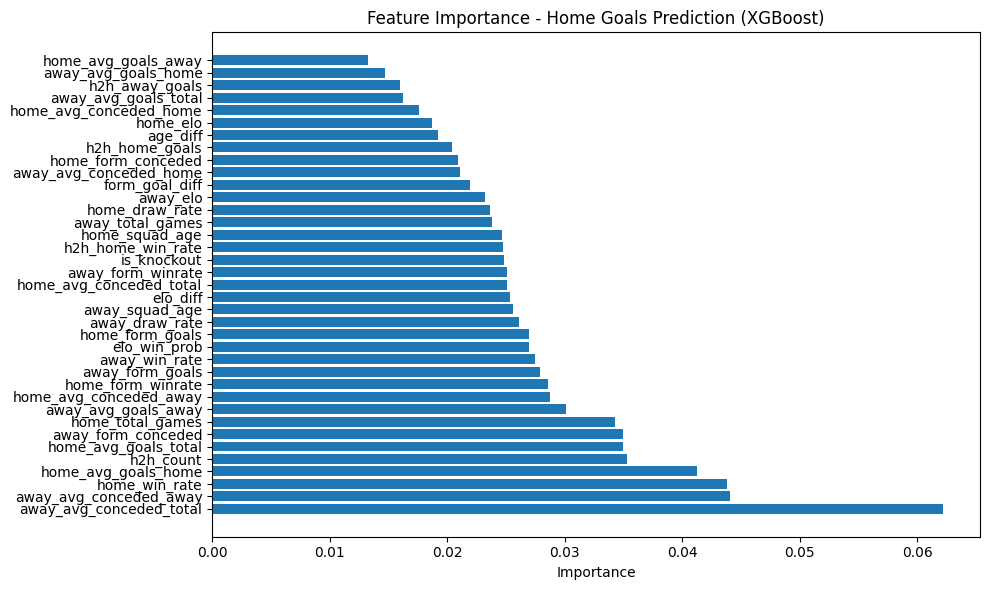

In [21]:
# Feature importance (for tree-based models)
print("🔍 FEATURE IMPORTANCE (XGBoost - Home Goals)\n")

xgb_model = models_home['XGBoost']['model']
feature_importance = xgb_model.feature_importances_

# Create dataframe for visualization
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Home Goals Prediction (XGBoost)')
plt.tight_layout()
plt.show()

### Step 10: Next Steps

Your models are now trained! Here are ways to improve:

1. **Add ELO Ratings** - Incorporate FIFA/ELO rankings
2. **Recent Form** - Calculate last 5 matches average
3. **Home Advantage** - Add binary home/away multiplier  
4. **Ensemble Voting** - Average predictions from all 4 models
5. **Hyperparameter Tuning** - Use GridSearchCV for optimal params
6. **Cross Validation** - Validate on multiple splits

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# 2026 FIFA WORLD CUP — PLAYER PERFORMANCE (Group Stage, as of June 24 2026)
# Source: ESPN, Al Jazeera, Sky Sports, France24
# ══════════════════════════════════════════════════════════════════════════════

player_stats_2026 = pd.DataFrame([
    {'Player': 'Lionel Messi',       'Team': 'Argentina',    'Goals': 5, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Erling Haaland',     'Team': 'Norway',       'Goals': 4, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Jonathan David',     'Team': 'Canada',       'Goals': 3, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Kylian Mbappé',      'Team': 'France',       'Goals': 3, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Leroy Sané',         'Team': 'Germany',      'Goals': 3, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Ferran Torres',      'Team': 'Spain',        'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 143},
    {'Player': 'Michael Olise',      'Team': 'France',       'Goals': 2, 'Assists': 3, 'Apps': 2, 'Mins': 180},
    {'Player': 'Alexander Isak',     'Team': 'Sweden',       'Goals': 2, 'Assists': 3, 'Apps': 2, 'Mins': 180},
    {'Player': 'Kai Havertz',        'Team': 'Germany',      'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 159},
    {'Player': 'Richarlison',        'Team': 'Brazil',       'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Folarin Balogun',    'Team': 'United States','Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Bukayo Saka',        'Team': 'England',      'Goals': 2, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Memphis Depay',      'Team': 'Netherlands',  'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Cristiano Ronaldo',  'Team': 'Portugal',     'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Rafael Santos Borré','Team': 'Colombia',     'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Jude Bellingham',    'Team': 'England',      'Goals': 1, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Pedri',              'Team': 'Spain',        'Goals': 1, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Takumi Minamino',    'Team': 'Japan',        'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Sébastien Haller',   'Team': "Côte d'Ivoire",'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Riyad Mahrez',       'Team': 'Algeria',      'Goals': 1, 'Assists': 1, 'Apps': 2, 'Mins': 161},
])
player_stats_2026['G+A']          = player_stats_2026['Goals'] + player_stats_2026['Assists']
player_stats_2026['Goals_per_90'] = (player_stats_2026['Goals'] / player_stats_2026['Mins'] * 90).round(2)
player_stats_2026['GA_per_90']    = (player_stats_2026['G+A'] / player_stats_2026['Mins'] * 90).round(2)

print("=" * 68)
print("  2026 FIFA WORLD CUP — PLAYER STATS (Group Stage, to June 24)")
print("=" * 68)

print("\n🥅 TOP SCORERS")
print(f"  {'Player':<22} {'Team':<18} {'G':>3} {'A':>3} {'G/90':>6}")
print("  " + "-" * 58)
for _, r in player_stats_2026.sort_values('Goals', ascending=False).head(10).iterrows():
    print(f"  {r['Player']:<22} {r['Team']:<18} {r['Goals']:>3} {r['Assists']:>3} {r['Goals_per_90']:>6.2f}")

print("\n🎯 TOP CONTRIBUTORS (G+A)")
print(f"  {'Player':<22} {'Team':<18} {'G':>3} {'A':>3} {'G+A':>5} {'(G+A)/90':>9}")
print("  " + "-" * 65)
for _, r in player_stats_2026.sort_values('G+A', ascending=False).head(10).iterrows():
    print(f"  {r['Player']:<22} {r['Team']:<18} {r['Goals']:>3} {r['Assists']:>3} {r['G+A']:>5} {r['GA_per_90']:>9.2f}")

print("\n📌 RECORDS (Source: ESPN / Al Jazeera / Sky Sports, June 2026)")
print("  • Messi (ARG): 18 career WC goals — ALL-TIME RECORD (surpassed Mbappé 16, Klose 16)")
print("  • Mbappé (FRA): 100 France caps at 27y 184d; 6 multi-goal WC games")
print("  • Haaland (NOR): 4 WC goals — Norwegian WC record; team wins in 16 straight when he scores")
print("  • Olise + Isak: joint-best assists (3 each)")
print("  • Messi scored in 6 consecutive WC games; involved in 12 goals + 3 assists last 9 WC matches")

  2026 FIFA WORLD CUP — PLAYER STATS (Group Stage, to June 24)

🥅 TOP SCORERS
  Player                 Team                 G   A   G/90
  ----------------------------------------------------------
  Lionel Messi           Argentina            5   2   2.50
  Erling Haaland         Norway               4   1   2.00
  Jonathan David         Canada               3   0   1.50
  Kylian Mbappé          France               3   1   1.50
  Leroy Sané             Germany              3   2   1.50
  Ferran Torres          Spain                2   0   1.26
  Michael Olise          France               2   3   1.00
  Alexander Isak         Sweden               2   3   1.00
  Kai Havertz            Germany              2   1   1.13
  Richarlison            Brazil               2   1   1.00

🎯 TOP CONTRIBUTORS (G+A)
  Player                 Team                 G   A   G+A  (G+A)/90
  -----------------------------------------------------------------
  Lionel Messi           Argentina            5   

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# 2026 COUNTRY PERFORMANCE — GROUP STANDINGS + MODEL PREDICTION vs ACTUAL
# ══════════════════════════════════════════════════════════════════════════════

standings_2026 = {
    'A': [('Mexico',2,0,1,3,0,6),('Korea Republic',1,0,1,2,1,3),('Czechia',0,1,1,2,2,1),('South Africa',0,1,1,0,2,1)],
    'B': [('Canada',1,1,0,7,1,4),('Switzerland',1,1,0,5,2,4),('Bosnia and Herzegovina',0,1,1,2,5,1),('Qatar',0,1,1,1,7,1)],
    'C': [('Brazil',2,0,0,4,1,4),('Morocco',1,1,0,2,1,4),('Scotland',1,1,0,1,1,3),('Haiti',0,0,2,0,4,0)],
    'D': [('United States',2,0,0,6,1,6),('Australia',1,0,1,2,2,3),('Paraguay',1,0,1,2,4,3),('Türkiye',0,0,2,0,3,0)],
    'E': [('Germany',2,0,0,9,2,6),("Côte d'Ivoire",1,0,1,2,2,3),('Ecuador',0,1,1,0,1,1),('Curaçao',0,1,1,1,7,1)],
    'F': [('Netherlands',1,1,0,7,3,4),('Japan',1,1,0,6,2,4),('Sweden',1,0,1,6,6,3),('Tunisia',0,0,2,1,9,0)],
    'G': [('Egypt',1,1,0,4,2,4),('IR Iran',0,2,0,2,2,2),('Belgium',0,2,0,1,1,2),('New Zealand',0,1,1,3,5,1)],
    'H': [('Spain',1,1,0,4,0,4),('Cape Verde',0,2,0,2,2,2),('Uruguay',0,2,0,3,3,2),('Saudi Arabia',0,1,1,1,5,1)],
    'I': [('France',2,0,0,6,1,6),('Norway',2,0,0,7,3,6),('Senegal',0,0,2,3,6,0),('Iraq',0,0,2,1,7,0)],
    'J': [('Argentina',2,0,0,5,0,6),('Austria',1,0,1,3,2,3),('Algeria',1,0,1,2,4,3),('Jordan',0,0,2,2,6,0)],
    'K': [('Colombia',2,0,0,4,1,6),('Portugal',1,1,0,6,1,4),('Congo DR',0,1,1,1,2,1),('Uzbekistan',0,0,2,1,8,0)],
    'L': [('England',1,1,0,4,2,4),('Ghana',1,1,0,1,0,4),('Croatia',1,0,1,3,4,3),('Panama',0,0,2,0,2,0)],
}

print("=" * 70)
print("  2026 FIFA WORLD CUP — GROUP STANDINGS (after 2 matchdays, June 24)")
print("=" * 70)
for grp, teams in standings_2026.items():
    print(f"\n  GROUP {grp}:")
    print(f"  {'Team':<25} {'W':>2} {'D':>2} {'L':>2} {'GF':>3} {'GA':>3} {'Pts':>4}")
    print("  " + "-" * 42)
    for name, w, d, l, gf, ga, pts in teams:
        print(f"  {name:<25} {w:>2} {d:>2} {l:>2} {gf:>3} {ga:>3} {pts:>4}")

# ── Model prediction vs actual ─────────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("  MODEL PREDICTION vs ACTUAL — 2026 GROUP STAGE RESULTS")
print("=" * 70)
print(f"\n  {'Match':<32} {'Actual':>8} {'Pred':>6} {'Result':>6} {'Correct':>8}")
print("  " + "-" * 65)

validation_matches = [
    ('Mexico',         'South Africa', 2, 0),
    ('Korea Republic', 'Czechia',      2, 1),
    ('United States',  'Paraguay',     4, 1),
    ('Australia',      'Türkiye',      2, 0),
    ('Brazil',         'Morocco',      1, 1),
    ('Germany',        'Curaçao',      7, 1),
    ('France',         'Senegal',      3, 1),
    ('Norway',         'Iraq',         4, 1),
    ('Argentina',      'Algeria',      3, 0),
    ('England',        'Croatia',      4, 2),
    ('Spain',          'Saudi Arabia', 4, 0),
    ('Canada',         'Qatar',        6, 0),
    ('France',         'Iraq',         3, 0),
    ('Argentina',      'Austria',      2, 0),
    ('Portugal',       'Uzbekistan',   5, 0),
]

correct_outcomes = 0
for home, away, ahg, aag in validation_matches:
    try:
        pred   = predict_match(home, away, all_models, scaler, feature_cols,
                               team_stats, df_processed, silent=True)
        phg    = max(0, round(pred['home_goals']))
        pag    = max(0, round(pred['away_goals']))
        a_out  = 'H' if ahg > aag  else ('D' if ahg == aag  else 'A')
        p_out  = 'H' if phg > pag  else ('D' if phg == pag  else 'A')
        ok     = a_out == p_out
        if ok: correct_outcomes += 1
        sym    = '✓' if ok else '✗'
        print(f"  {home+' vs '+away:<32} {ahg}-{aag:>1}   {phg}-{pag:>1}  {p_out:>6}  {sym:>8}")
    except Exception as e:
        print(f"  {home} vs {away}: ERROR — {e}")

total = len(validation_matches)
print(f"\n  Outcome accuracy on 2026 actual matches: {correct_outcomes}/{total} = {correct_outcomes/total:.1%}")
print(f"  Ensemble test-set accuracy              : {ensemble_acc:.1%}")

  2026 FIFA WORLD CUP — GROUP STANDINGS (after 2 matchdays, June 24)

  GROUP A:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Mexico                     2  0  1   3   0    6
  Korea Republic             1  0  1   2   1    3
  Czechia                    0  1  1   2   2    1
  South Africa               0  1  1   0   2    1

  GROUP B:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Canada                     1  1  0   7   1    4
  Switzerland                1  1  0   5   2    4
  Bosnia and Herzegovina     0  1  1   2   5    1
  Qatar                      0  1  1   1   7    1

  GROUP C:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Brazil                     2  0  0   4   1    4
  Morocco                    1  1  0   2   1    4
  Scotland                   1  1  0   1   1    3
  Haiti                      0  0  2   0   4    0

  GROUP D

  Mexico vs South Africa           2-0   1-1       D         ✗


  Korea Republic vs Czechia        2-1   2-1       H         ✓


  United States vs Paraguay        4-1   2-1       H         ✓


  Australia vs Türkiye             2-0   1-1       D         ✗


...

  Spain vs Saudi Arabia            4-0   3-0       H         ✓


  Canada vs Qatar                  6-0   4-1       H         ✓


  France vs Iraq                   3-0   4-0       H         ✓


  Argentina vs Austria             2-0   2-0       H         ✓


  Portugal vs Uzbekistan           5-0   5-0       H         ✓

  Outcome accuracy on 2026 actual matches: 12/15 = 80.0%
  Ensemble test-set accuracy              : 63.1%
